In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("ticks")
plt.rc("axes.spines", top=False, right=False)

# 1. HaveWorkedWith

In [3]:
df = pd.read_csv("../data/survey_data_updated 5.csv")

In [4]:
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

## 1.1 Str.split

In [5]:
df["Languages"] = df.LanguageHaveWorkedWith.str.split(";")
df["Databases"] = df.DatabaseHaveWorkedWith.str.split(";")
df["Webframes"] = df.WebframeHaveWorkedWith.str.split(";")
df["Platforms"] = df.PlatformHaveWorkedWith.str.split(";")
df = df[["ResponseId","Languages", "Databases", "Webframes", "Platforms"]]

## 1.2. Explode

In [6]:
df_exploded = df.explode("Languages")

In [7]:
df_exploded = df_exploded.explode("Databases")

In [8]:
df_exploded = df_exploded.explode("Webframes")

In [9]:
df_exploded = df_exploded.explode("Platforms")

In [10]:
df_exploded.shape

(29021148, 5)

## 1.3 Groupby

In [11]:
df_group = df_exploded.groupby(["Languages", "Databases", "Webframes", "Platforms"]).size().reset_index(name="Count")
df_group
# print(df_exploded[["Languages", "Databases", "Webframes", "Platforms"]].map(type).value_counts())

,Languages,Databases,Webframes,Platforms,Count
0,Ada,BigQuery,ASP.NET,Alibaba Cloud,13
1,Ada,BigQuery,ASP.NET,Amazon Web Services (AWS),20
2,Ada,BigQuery,ASP.NET,Cloudflare,16
3,Ada,BigQuery,ASP.NET,Colocation,12
4,Ada,BigQuery,ASP.NET,Databricks,13
...,...,...,...,...,...
1666975,Zig,TiDB,jQuery,Scaleway,10
1666976,Zig,TiDB,jQuery,Supabase,10
1666977,Zig,TiDB,jQuery,VMware,9
1666978,Zig,TiDB,jQuery,Vercel,10


In [12]:
# df_group.to_csv("first_tab.csv")

## 1.4. Languages Graph

In [13]:
df_dummy = df_group.groupby("Languages")["Count"].sum().reset_index(name="Count").sort_values("Count", ascending=False).head(10)
df_dummy

,Languages,Count
22,JavaScript,1634962
40,SQL,1472573
19,HTML/CSS,1464896
44,TypeScript,1399762
36,Python,1308431
32,PHP,1025751
21,Java,1024323
3,Bash/Shell (all shells),1013740
5,C#,904902
6,C++,807998


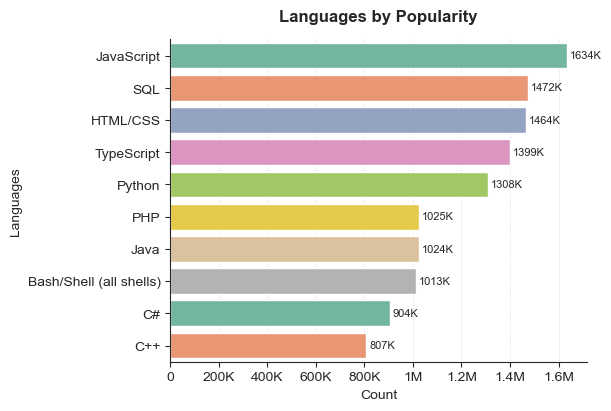

In [14]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
sns.barplot(data=df_dummy,
			x="Count",
			y="Languages",
			hue="Languages",
			palette="Set2",
			ax=ax)
plt.xticks(ticks=np.arange(0, 1700000, 200000),
		   labels=["0", "200K", "400K", "600K", "800K", "1M", "1.2M", "1.4M", "1.6M"])
plt.title("Languages by Popularity", fontweight=700, y=1.03)
plt.grid(axis="x", lw=0.5, ls=":")
for container in ax.containers:
	ax.bar_label(container,
				 labels=[f"{int(v / 1000)}K" for v in container.datavalues],
				 padding=2,
				 fontsize=8)
fig.savefig("languages.png");

## 1.5. Databases Graph 

In [15]:
df_dummy = df_group.groupby("Databases")["Count"].sum().reset_index(name="Count").sort_values("Count", ascending=False).head(10)
df_dummy

,Databases,Count
26,PostgreSQL,2092094
23,MySQL,1933459
30,SQLite,1791198
22,MongoDB,1630468
29,Redis,1506128
21,Microsoft SQL Server,1307952
19,MariaDB,1298940
12,Elasticsearch,1142986
14,Firebase Realtime Database,904814
25,Oracle,879452


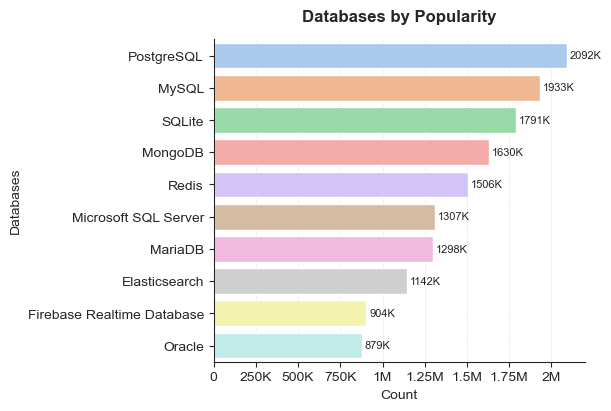

In [16]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
sns.barplot(data=df_dummy,
			x="Count",
			y="Databases",
			hue="Databases",
			palette="pastel",
			ax=ax)
plt.xticks(ticks=np.arange(0, 2000001, 250000),
		   labels=["0", "250K", "500K", "750K", "1M", "1.25M", "1.5M", "1.75M", "2M"])
plt.title("Databases by Popularity", fontweight=700, y=1.03)
plt.grid(axis="x", lw=0.5, ls=":")
for container in ax.containers:
	ax.bar_label(container,
				 labels=[f"{int(v / 1000)}K" for v in container.datavalues],
				 padding=2,
				 fontsize=8)
fig.savefig("databases.png");

# 2. WantToWorkWith

In [18]:
df = pd.read_csv("../data/survey_data_updated 5.csv")

## 2.1 Str.split

In [19]:
df["Languages"] = df.LanguageWantToWorkWith.str.split(";")
df["Databases"] = df.DatabaseWantToWorkWith.str.split(";")
df["Webframes"] = df.WebframeWantToWorkWith.str.split(";")
df["Platforms"] = df.PlatformWantToWorkWith.str.split(";")
df = df[["ResponseId","Languages", "Databases", "Webframes", "Platforms"]]

## 2.2 Explode

In [20]:
df_exploded = df.explode("Languages")

In [21]:
df_exploded = df_exploded.explode("Databases")

In [22]:
df_exploded = df_exploded.explode("Webframes")

In [23]:
df_exploded = df_exploded.explode("Platforms")

In [24]:
df_exploded.shape

(39691094, 5)

In [25]:
# df_group.to_csv("second_tab.csv")

## 2.3 Groupby

In [26]:
df_group = df_exploded.groupby(["Languages", "Databases", "Webframes", "Platforms"]).size().reset_index(name="Count")
df_group

,Languages,Databases,Webframes,Platforms,Count
0,Ada,BigQuery,ASP.NET,Alibaba Cloud,19
1,Ada,BigQuery,ASP.NET,Amazon Web Services (AWS),17
2,Ada,BigQuery,ASP.NET,Cloudflare,18
3,Ada,BigQuery,ASP.NET,Colocation,17
4,Ada,BigQuery,ASP.NET,Databricks,17
...,...,...,...,...,...
1666975,Zig,TiDB,jQuery,Scaleway,17
1666976,Zig,TiDB,jQuery,Supabase,17
1666977,Zig,TiDB,jQuery,VMware,15
1666978,Zig,TiDB,jQuery,Vercel,18


## 2.4 Languages Graph

In [28]:
df_dummy = df_group.groupby("Languages")["Count"].sum().reset_index(name="Count").sort_values("Count", ascending=False).head(10)
df_dummy

,Languages,Count
22,JavaScript,1585875
40,SQL,1571465
44,TypeScript,1521979
36,Python,1504472
19,HTML/CSS,1447727
17,Go,1236050
39,Rust,1151142
3,Bash/Shell (all shells),1048243
21,Java,999519
32,PHP,996823


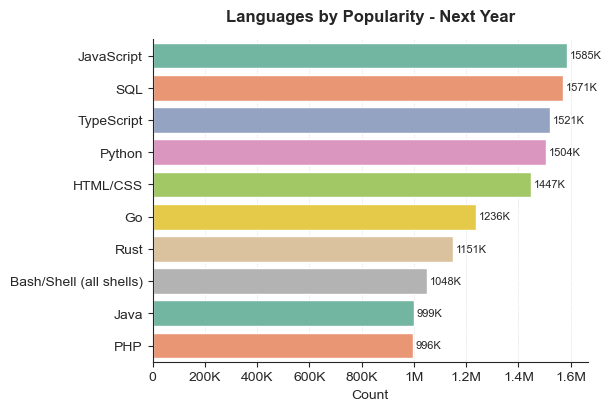

In [29]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
sns.barplot(data=df_dummy,
			x="Count",
			y="Languages",
			hue="Languages",
			palette="Set2",
			ax=ax)
plt.xticks(ticks=np.arange(0, 1700000, 200000),
		   labels=["0", "200K", "400K", "600K", "800K", "1M", "1.2M", "1.4M", "1.6M"])
plt.ylabel("")
plt.title("Languages by Popularity - Next Year", fontweight=700, y=1.03)
plt.grid(axis="x", lw=0.5, ls=":")
for container in ax.containers:
	ax.bar_label(container,
				 labels=[f"{int(v / 1000)}K" for v in container.datavalues],
				 padding=2,
				 fontsize=8)
fig.savefig("languages.png");

## 2.5 Databases Graph 

In [30]:
df_dummy = df_group.groupby("Databases")["Count"].sum().reset_index(name="Count").sort_values("Count", ascending=False).head(10)
df_dummy

,Databases,Count
26,PostgreSQL,2211021
23,MySQL,1799978
30,SQLite,1771333
29,Redis,1762685
22,MongoDB,1749035
12,Elasticsearch,1466117
19,MariaDB,1374206
21,Microsoft SQL Server,1362244
14,Firebase Realtime Database,1258061
33,Supabase,1246197


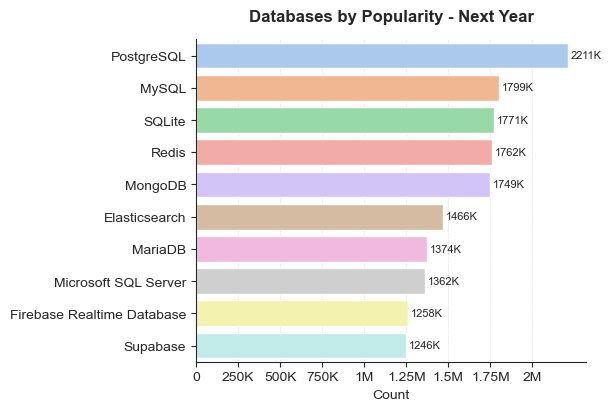

In [31]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
sns.barplot(data=df_dummy,
			x="Count",
			y="Databases",
			hue="Databases",
			palette="pastel",
			ax=ax)
plt.xticks(ticks=np.arange(0, 2000001, 250000),
		   labels=["0", "250K", "500K", "750K", "1M", "1.25M", "1.5M", "1.75M", "2M"])
plt.ylabel("")
plt.title("Databases by Popularity - Next Year", fontweight=700, y=1.03)
plt.grid(axis="x", lw=0.5, ls=":")
for container in ax.containers:
	ax.bar_label(container,
				 labels=[f"{int(v / 1000)}K" for v in container.datavalues],
				 padding=2,
				 fontsize=8)
fig.savefig("databases.png");

# 3. demographics

In [34]:
df = pd.read_csv("../data/survey_data_updated 5.csv")

In [35]:
df.Age.value_counts()

Age
25-34 years old       7788
35-44 years old       5149
18-24 years old       2988
45-54 years old       2053
55-64 years old        632
Under 18 years old     136
65 years or older       75
Prefer not to say       24
Name: count, dtype: int64

In [36]:
categories=[
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
    "Prefer not to say"  
]

df.Age = pd.Categorical(df.Age, ordered=True, categories=categories)

# df["Languages"] = df.LanguageWantToWorkWith.str.split(";")
# df["Databases"] = df.DatabaseWantToWorkWith.str.split(";")
# df["Webframes"] = df.WebframeWantToWorkWith.str.split(";")
# df["Platforms"] = df.PlatformWantToWorkWith.str.split(";")
df = df[["ResponseId","Country", "Age", "EdLevel"]]

In [37]:
df = df.groupby(["Country", "Age", "EdLevel"]).size().reset_index(name="Count")
df

,Country,Age,EdLevel,Count
0,Afghanistan,Under 18 years old,"Secondary school (e.g. American high school, G...",1
1,Afghanistan,25-34 years old,"Bachelor's degree (B.A., B.S., B.Eng., etc.)",5
2,Afghanistan,25-34 years old,"Master's degree (M.A., M.S., M.Eng., MBA, etc.)",3
3,Afghanistan,25-34 years old,Primary/elementary school,2
4,Afghanistan,25-34 years old,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",1
...,...,...,...,...
1974,Zimbabwe,25-34 years old,"Master's degree (M.A., M.S., M.Eng., MBA, etc.)",2
1975,Zimbabwe,25-34 years old,"Secondary school (e.g. American high school, G...",1
1976,Zimbabwe,25-34 years old,Some college/university study without earning ...,1
1977,Zimbabwe,35-44 years old,"Bachelor's degree (B.A., B.S., B.Eng., etc.)",1


In [38]:
# df.to_csv("third_tab.csv")